In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

# buat kategori berdasarkan median_income agar tes set sesuai dengan proporsi ditribusi median_income
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

# buat data train dan test dengan stratified sampling berdasarkan income_cat
train_set, test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

# cek hasil proporsi income_cat di test set dan train set
test_set["income_cat"].value_counts() / len(test_set)
train_set["income_cat"].value_counts() / len(train_set)


# hapus kolom income_cat karena sudah tidak diperlukan lagi
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)



In [11]:
housing= train_set.copy()

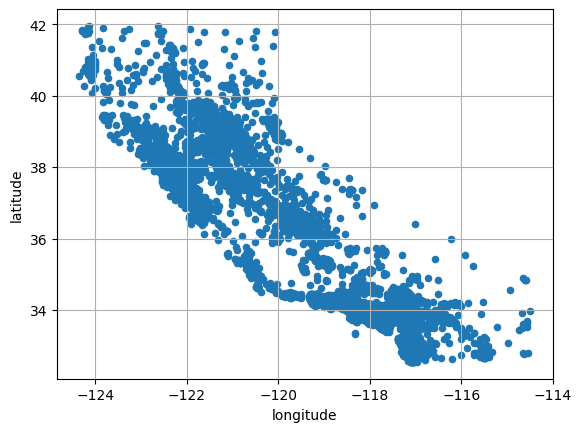

In [15]:
#viusalisasi data geografis
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

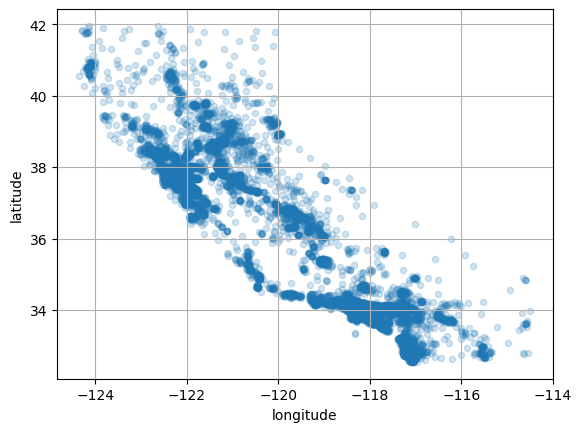

In [16]:
#viusalisasi data geografis revision
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

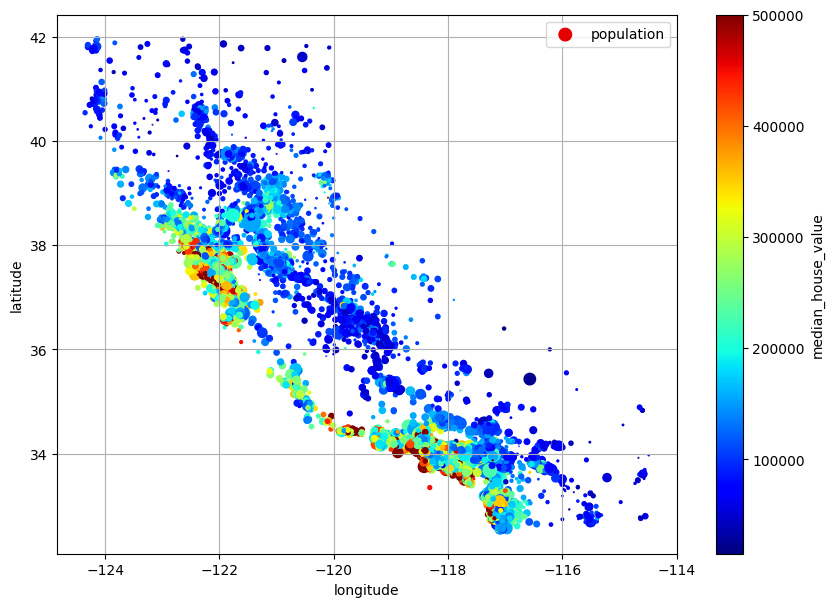

In [38]:
#viusalisasi data geografis lebih kompleks dengan ukuran dan warna berdasarkan populasi dan harga
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
 s=housing["population"] / 100, label="population",
 c="median_house_value", cmap="jet", colorbar=True,
 legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [6]:
#hitung korelasi antara fitur
housing_korelasi = housing.corr(numeric_only=True)

In [4]:
housing_korelasi

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [7]:
#menghitung korelasi antara median_house_value dengan fitur lainnya
housing_korelasi["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


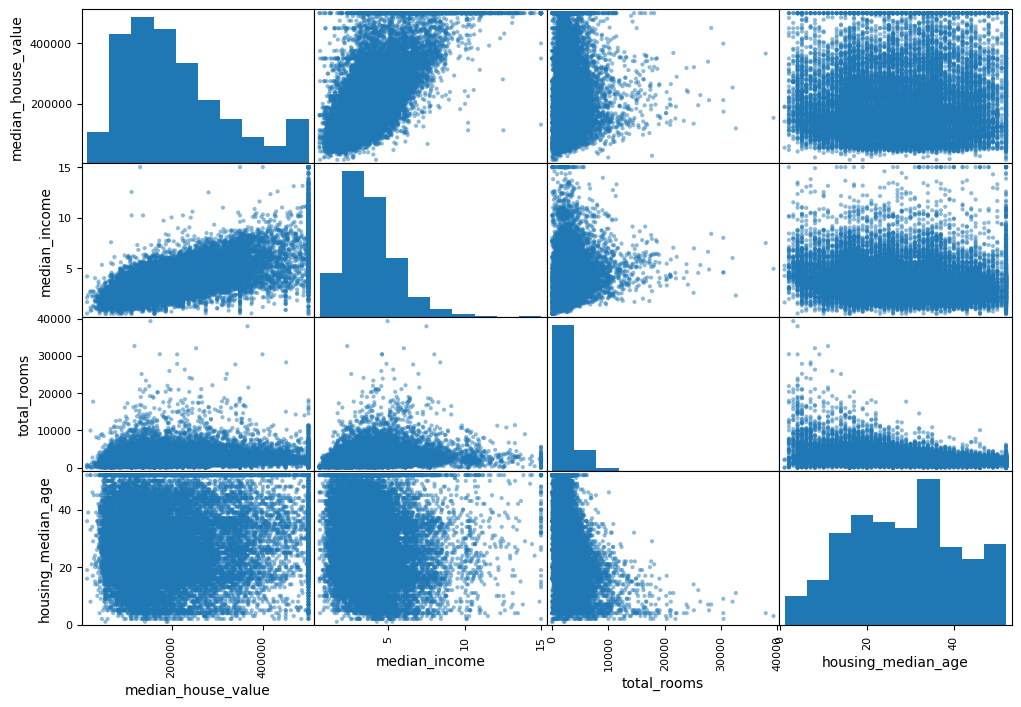

In [8]:
#visualisasi korelasi
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

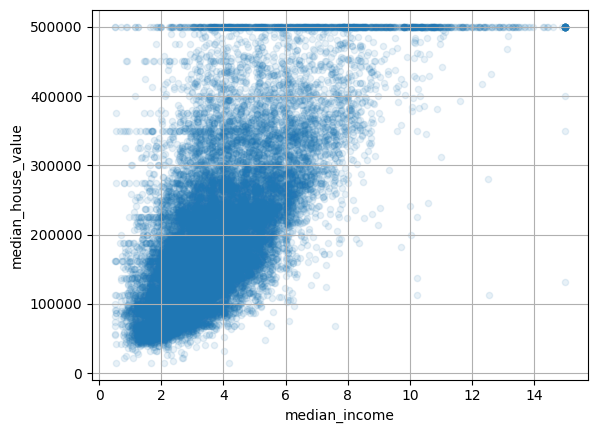

In [14]:
#plot median_income vs median_house_value
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()